# QClus Tutorial - Heart

This tutorial assumes you have followed the installation instructions in the README and have the necessary packages installed. If you have not, please refer to the README for installation instructions.

Furthermore, it assumes you have a 10X .h5 counts file and the fraction unspliced file. If you do not have the fraction unspliced file, you can follow the instructions in the README to generate it.

We begin by loading the necessary packages and data.

In [1]:
import qclus as qc
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

splicing_path = "../../data/fraction_unspliced.csv"
counts_path = "../../data/counts.h5"

fraction_unspliced = pd.read_csv(splicing_path, index_col=0)

fraction_unspliced.head()

,fraction_unspliced
AAACGCTCAGATACCT,0.259897
AAACCCAGTGAATGTA,0.774209
AAACGAACATTGACCA,0.526074
AAACCCAAGCAGCACA,0.832765
AAACGAATCCACAGGC,0.794653


Please make sure that the fraction unspliced file is in the correct format as shown above. The index should be the cell barcodes and there should be a column named "fraction_unspliced".

From here, running QClus is simple. We just need to call the run_qclus function with the counts file and the fraction unspliced file. The function will return an AnnData object with the qclus column annotated.

In [2]:
adata = qc.run_qclus(counts_path, fraction_unspliced)
adata

AnnData object with n_obs × n_vars = 25096 × 36601
    obs: 'original_barcode', 'fraction_unspliced', 'n_genes_by_counts', 'total_counts', 'total_counts_nuclear', 'pct_counts_nuclear', 'score_nuclear', 'total_counts_MT', 'pct_counts_MT', 'score_MT', 'total_counts_CM_cyto', 'pct_counts_CM_cyto', 'score_CM_cyto', 'total_counts_CM_nucl', 'pct_counts_CM_nucl', 'score_CM_nucl', 'total_counts_VEC', 'pct_counts_VEC', 'score_VEC', 'total_counts_PER', 'pct_counts_PER', 'score_PER', 'total_counts_SMC', 'pct_counts_SMC', 'score_SMC', 'total_counts_AD', 'pct_counts_AD', 'score_AD', 'total_counts_SC', 'pct_counts_SC', 'score_SC', 'total_counts_N', 'pct_counts_N', 'score_N', 'total_counts_EEC', 'pct_counts_EEC', 'score_EEC', 'total_counts_FB', 'pct_counts_FB', 'score_FB', 'total_counts_L', 'pct_counts_L', 'score_L', 'total_counts_MESO', 'pct_counts_MESO', 'score_MESO', 'total_counts_MP', 'pct_counts_MP', 'score_MP', 'pct_counts_nonCM', 'score_scrublet', 'kmeans', 'qclus'
    var: 'gene_ids', 'featur

Now we can perform a check to see how many nuclei were filtered at each step and how many passed.

In [3]:
adata.obs.qclus.value_counts()

qclus
passed               8142
outlier filter       5769
initial filter       4236
clustering filter    4231
scrublet filter      2718
Name: count, dtype: int64

Now let's check what the distribution of the fraction unspliced, pct counts MT, pct counts nuclear, and total counts look like across the different filtering steps.

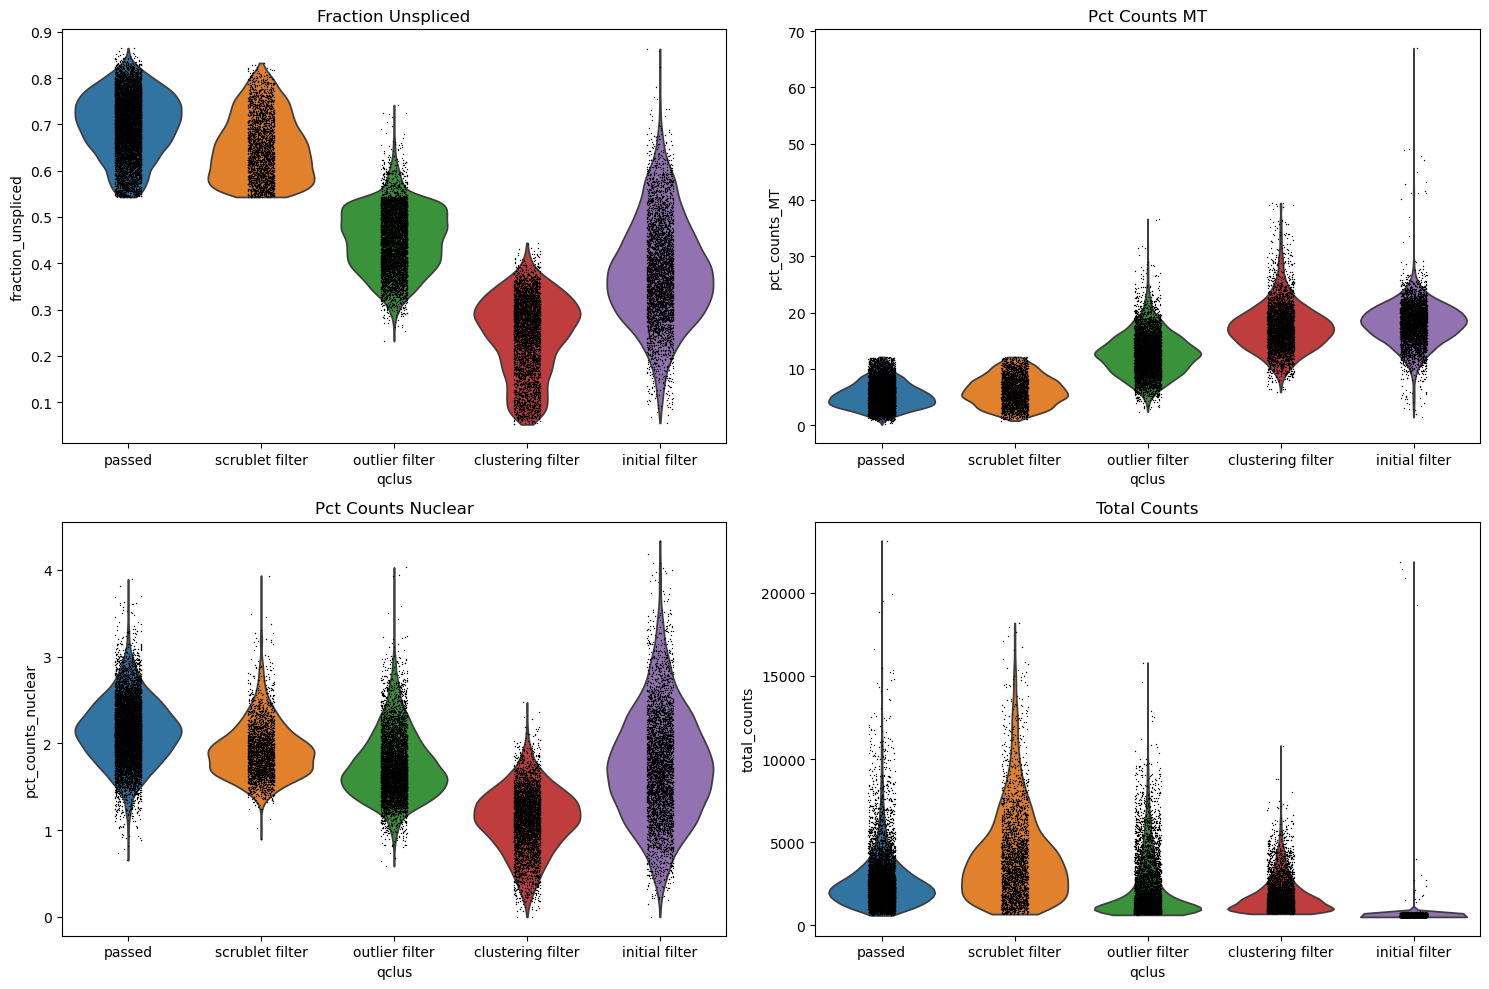

In [4]:
# Define the desired order of qclus categories
desired_order = ['passed', 'scrublet filter', 'outlier filter', 'clustering filter', 'initial filter']

# Get the unique values present in the qclus column
unique_qclus_values = adata.obs['qclus'].unique().tolist()

# Filter the desired order to only include categories that are present in the data
qclus_order = [category for category in desired_order if category in unique_qclus_values]

# Ensure the qclus column is a categorical type with the specified order
adata.obs['qclus'] = adata.obs['qclus'].astype('category')
adata.obs['qclus'] = adata.obs['qclus'].cat.reorder_categories(qclus_order, ordered=True)

# Create the figure and subplots
fig, axs = plt.subplots(2, 2, figsize=(15, 10))

# Plot each subplot
sc.pl.violin(adata, 'fraction_unspliced', groupby='qclus', order=qclus_order, ax=axs[0, 0], show=False)
axs[0, 0].set_title('Fraction Unspliced')

sc.pl.violin(adata, 'pct_counts_MT', groupby='qclus', order=qclus_order, ax=axs[0, 1], show=False)
axs[0, 1].set_title('Pct Counts MT')

sc.pl.violin(adata, 'pct_counts_nuclear', groupby='qclus', order=qclus_order, ax=axs[1, 0], show=False)
axs[1, 0].set_title('Pct Counts Nuclear')

sc.pl.violin(adata, 'total_counts', groupby='qclus', order=qclus_order, ax=axs[1, 1], show=False)
axs[1, 1].set_title('Total Counts')

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

Now we filter out the nuclei flagged by the initial filter and visualize a UMAP of the clustering features.

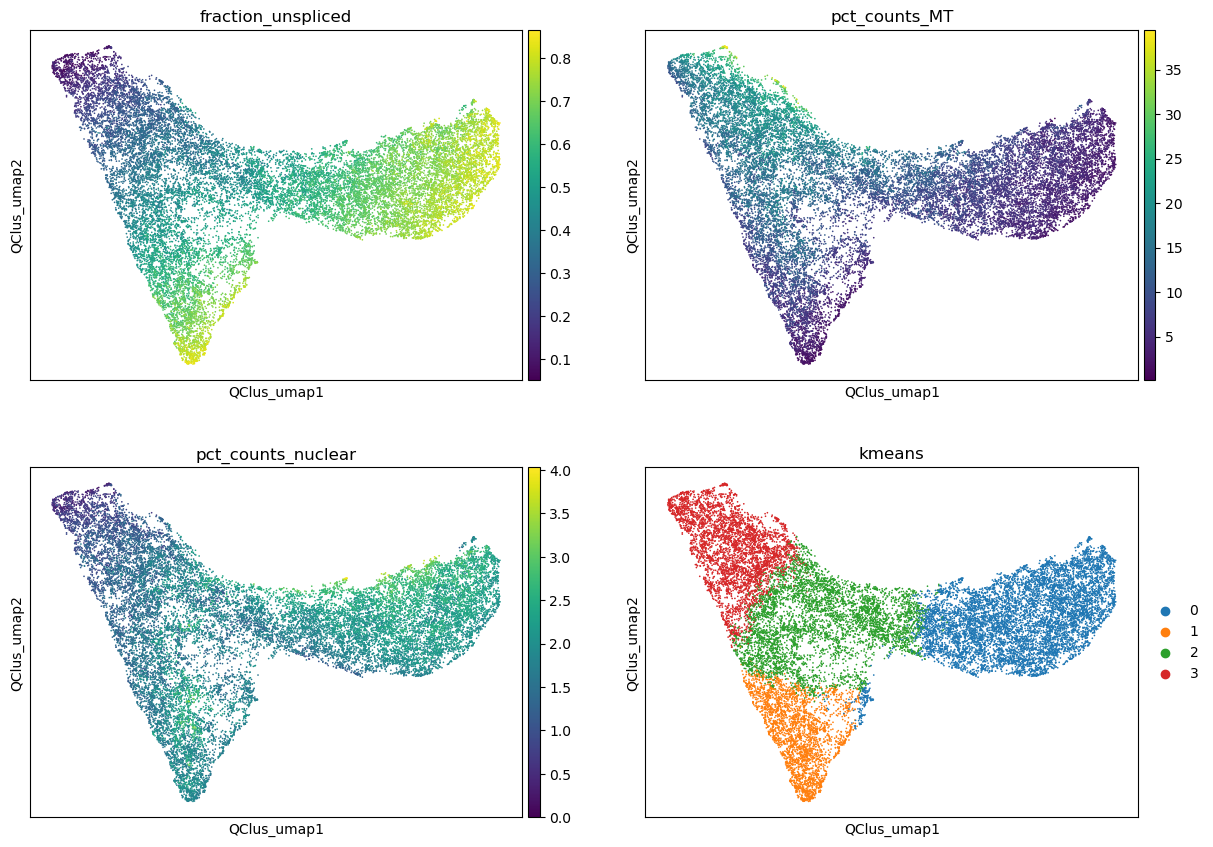

In [5]:
#filter out initial_filter annotated cells
adata = adata[adata.obs.qclus!="initial filter"]
adata.obsm["QClus_umap"] = adata.uns["QClus_umap"]

sc.pl.embedding(adata, basis="QClus_umap", color=["fraction_unspliced", "pct_counts_MT", "pct_counts_nuclear", "kmeans"], ncols=2)

Now we can perform standard processing for visualization purposes and visualize the data without filtering.

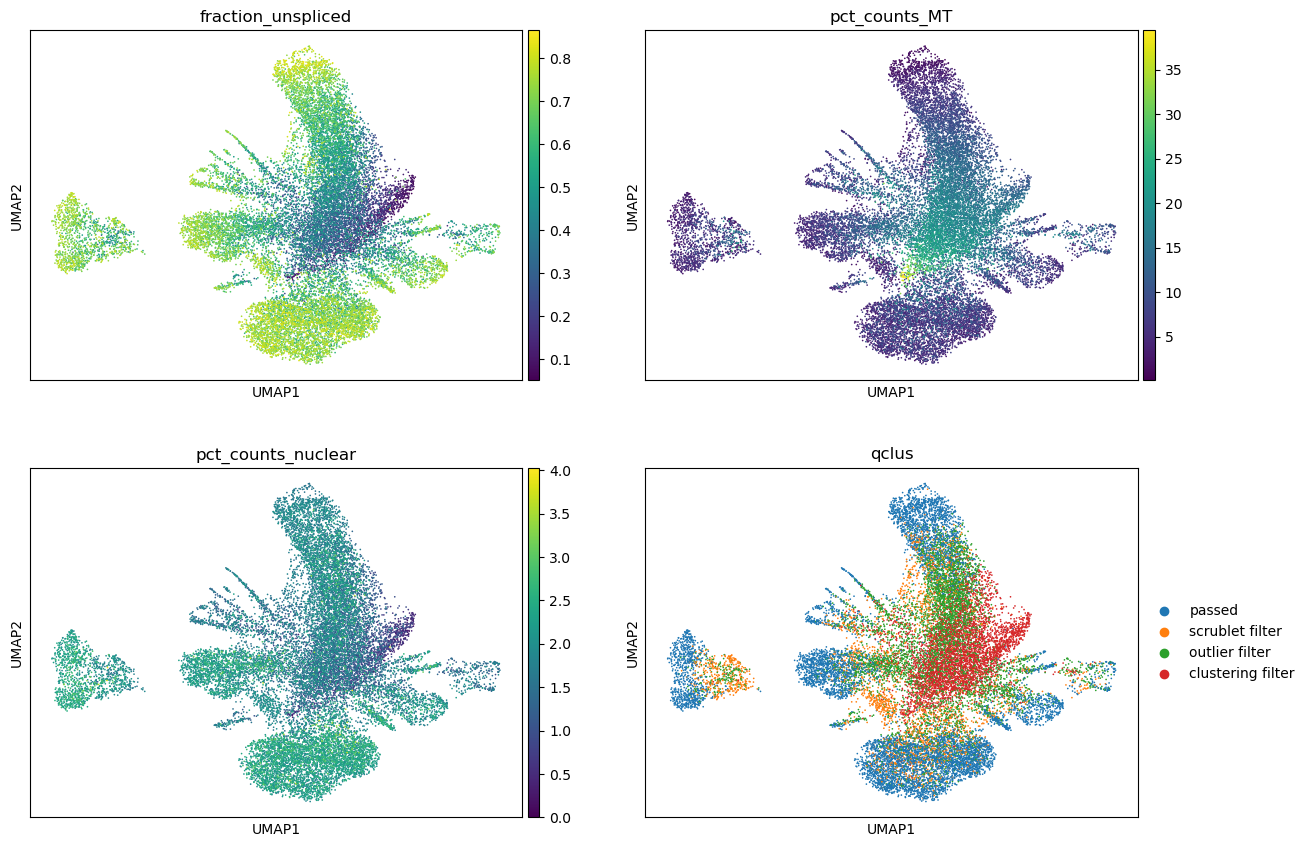

In [6]:
#run standard processing for visualization purposes
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

#save raw dataset and filter genes
adata.raw = adata
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
sc.pp.filter_genes(adata, min_cells=10)
adata = adata[:, adata.var.highly_variable]

sc.pp.regress_out(adata, ['total_counts', 'pct_counts_MT'], n_jobs = 4)
sc.pp.scale(adata, max_value=10)

sc.tl.pca(adata, svd_solver='randomized')
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
sc.tl.umap(adata)
sc.tl.leiden(adata, key_added="leiden")

sc.pl.umap(adata, color=["fraction_unspliced", "pct_counts_MT", "pct_counts_nuclear", "qclus"], ncols=2)

Up until now, we have been visualizing the data without filtering out any nuclei (discounting the initial filter). Now, we will filter out the nuclei flagged by QClus and visualize the filtered data.

In [7]:
adata = adata[adata.obs.qclus=="passed"]
adata

View of AnnData object with n_obs × n_vars = 8142 × 2978
    obs: 'original_barcode', 'fraction_unspliced', 'n_genes_by_counts', 'total_counts', 'total_counts_nuclear', 'pct_counts_nuclear', 'score_nuclear', 'total_counts_MT', 'pct_counts_MT', 'score_MT', 'total_counts_CM_cyto', 'pct_counts_CM_cyto', 'score_CM_cyto', 'total_counts_CM_nucl', 'pct_counts_CM_nucl', 'score_CM_nucl', 'total_counts_VEC', 'pct_counts_VEC', 'score_VEC', 'total_counts_PER', 'pct_counts_PER', 'score_PER', 'total_counts_SMC', 'pct_counts_SMC', 'score_SMC', 'total_counts_AD', 'pct_counts_AD', 'score_AD', 'total_counts_SC', 'pct_counts_SC', 'score_SC', 'total_counts_N', 'pct_counts_N', 'score_N', 'total_counts_EEC', 'pct_counts_EEC', 'score_EEC', 'total_counts_FB', 'pct_counts_FB', 'score_FB', 'total_counts_L', 'pct_counts_L', 'score_L', 'total_counts_MESO', 'pct_counts_MESO', 'score_MESO', 'total_counts_MP', 'pct_counts_MP', 'score_MP', 'pct_counts_nonCM', 'score_scrublet', 'kmeans', 'qclus', 'leiden'
    var: 'ge

From here we can visualize the data after we have removed the nuclei flagged by QClus.

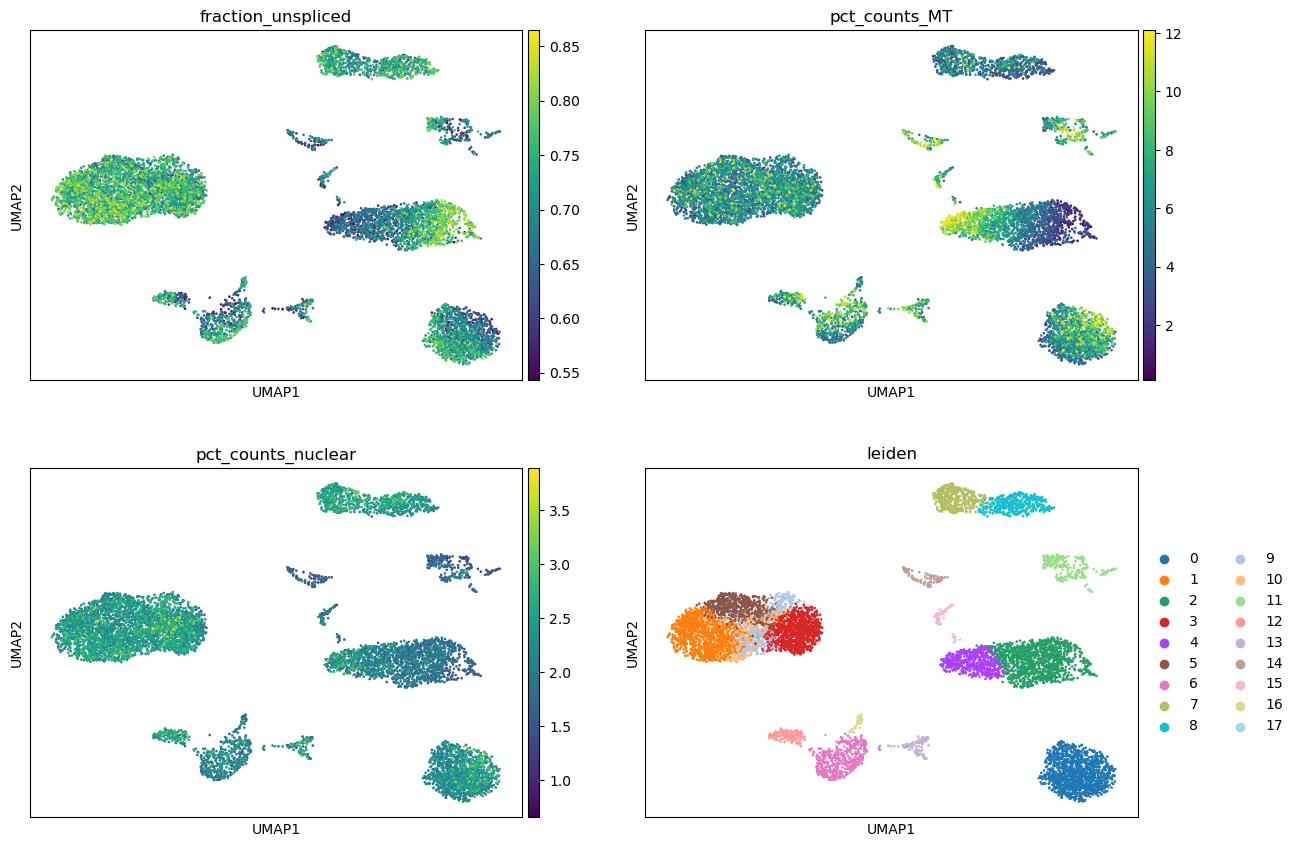

In [8]:
sc.tl.pca(adata, svd_solver='randomized')
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
sc.tl.umap(adata)
sc.tl.leiden(adata, key_added="leiden")

sc.pl.umap(adata, color=["fraction_unspliced", "pct_counts_MT", "pct_counts_nuclear", "leiden"], ncols=2)